# 09 — Combining Decay Weighting with Volatility Scaling

**Lesson:** Each mitigation fixes a different problem — decay fixes ordering (old returns matter less), vol scaling fixes magnitudes (returns rescaled to current vol). Combining them should, in theory, give the best of both worlds. But does it actually help, or does it just add complexity?

This notebook compares all four methods side by side: equal-weighted, decay-weighted, vol-scaled, and the combination of decay + vol scaling.

## Parameters

In [1]:
# Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"
END_DATE = None
VAR_WINDOW = 252
VOL_WINDOW = 20
LAMBDA = 0.94
CONFIDENCE = 0.95

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.historical_var import historical_var
from src.decay import decay_var
from src.rolling import rolling_var, rolling_decay_var
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
daily_returns = prepare_returns(prices)

Prepared 2147 daily returns (2018-01-03 to 2026-07-21) from 2148 price observations.


---

## Part A: What each method fixes

A quick reminder before we combine them:

| Method | Fixes ordering? | Fixes magnitudes? | Free parameters |
|--------|:---:|:---:|---|
| Equal-weighted | No | No | 1 (window) |
| Decay-weighted (λ=0.94) | Yes | No | 2 (window, λ) |
| Vol-scaled (20d vol) | No | Yes | 2 (window, vol window) |
| **Combined** | **Yes** | **Yes** | **3** (window, λ, vol window) |

The combined method: vol-scale each return to current vol, then apply decay weights to the scaled returns.

---

## Part B: Implement the combined method

Rolling computation: for each day, (1) vol-scale the window returns, (2) apply decay_var to the scaled returns.

In [4]:
# Compute all four methods
trailing_vol = daily_returns.rolling(window=VOL_WINDOW).std().clip(lower=0.001)

equal_result = rolling_var(daily_returns, window=VAR_WINDOW, confidence=CONFIDENCE)
decay_result = rolling_decay_var(daily_returns, window=VAR_WINDOW, lam=LAMBDA, confidence=CONFIDENCE)

# Vol-scaled equal-weighted
first_day = VAR_WINDOW + VOL_WINDOW
print(f"Computing vol-scaled and combined VaR (starting day {first_day})...")

volscaled_var, volscaled_next, volscaled_breach, volscaled_dates = [], [], [], []
combined_var, combined_next, combined_breach, combined_dates = [], [], [], []

for day in range(first_day, len(daily_returns)):
    window_rets = daily_returns.iloc[day - VAR_WINDOW : day]
    window_idx = window_rets.index

    vol_current = trailing_vol.loc[window_idx[-1]]
    vol_history = trailing_vol.loc[window_idx].values
    if np.isnan(vol_history).any():
        continue

    scaled_rets = window_rets.values * (vol_current / vol_history)

    # Vol-scaled equal-weighted (historical_var on scaled returns)
    vs_var = historical_var(scaled_rets, confidence=CONFIDENCE)
    # Combined: decay_var on scaled returns (newest first)
    cb_var = decay_var(scaled_rets[::-1], lam=LAMBDA, confidence=CONFIDENCE)

    next_ret = daily_returns.iloc[day]
    volscaled_var.append(vs_var)
    volscaled_next.append(next_ret)
    volscaled_breach.append(-next_ret > vs_var)
    volscaled_dates.append(daily_returns.index[day])

    combined_var.append(cb_var)
    combined_next.append(next_ret)
    combined_breach.append(-next_ret > cb_var)
    combined_dates.append(daily_returns.index[day])

volscaled_result = pd.DataFrame(
    {"VaR": volscaled_var, "NextReturn": volscaled_next, "Breach": volscaled_breach},
    index=pd.DatetimeIndex(volscaled_dates, name="Date"))

combined_result = pd.DataFrame(
    {"VaR": combined_var, "NextReturn": combined_next, "Breach": combined_breach},
    index=pd.DatetimeIndex(combined_dates, name="Date"))

for name, res in [
    ("Equal", equal_result), ("Decay", decay_result),
    ("Vol-scaled", volscaled_result), ("Combined", combined_result),
]:
    print(f"{name:<15}: {res['Breach'].sum():>4} breaches ({res['Breach'].mean():.3%})")

Computing vol-scaled and combined VaR (starting day 272)...


Equal          :   90 breaches (4.749%)
Decay          :  113 breaches (5.963%)
Vol-scaled     :  116 breaches (6.187%)
Combined       :  129 breaches (6.880%)


### All four methods overlaid

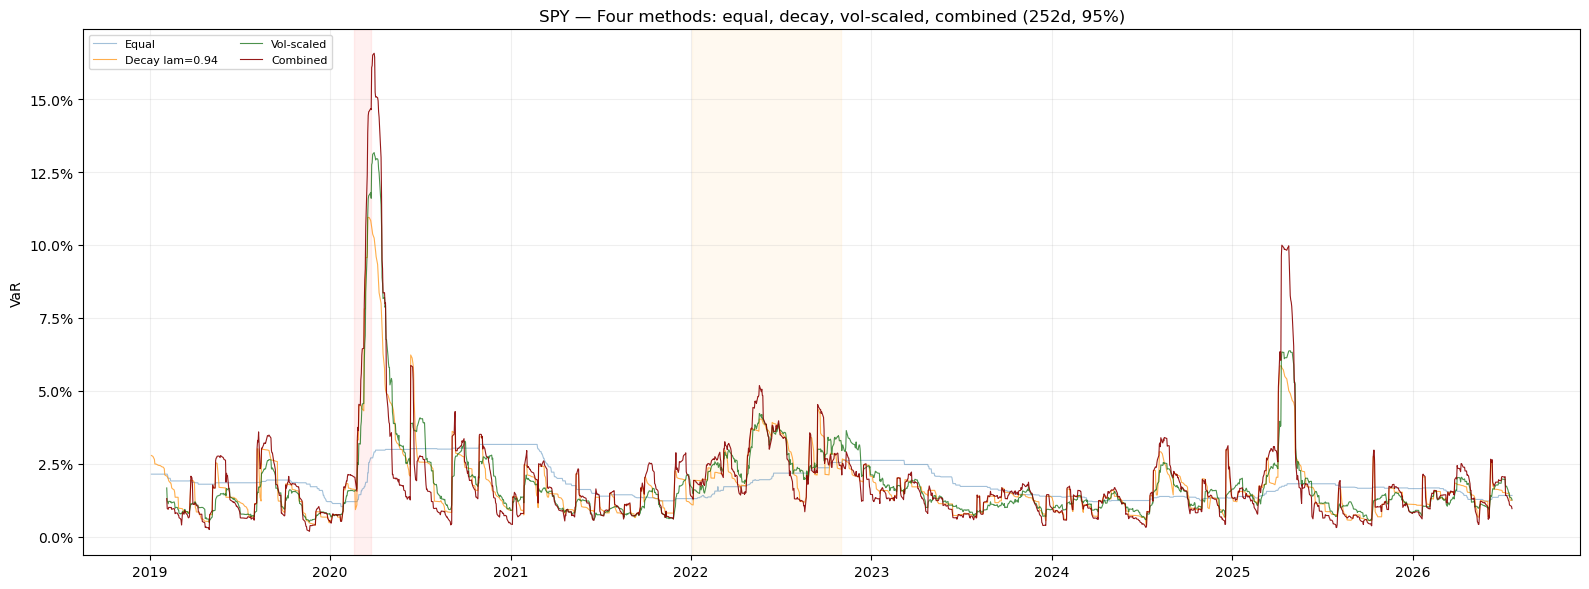

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))

methods = [
    (equal_result, "Equal", "steelblue", 0.5),
    (decay_result, "Decay lam=0.94", "darkorange", 0.7),
    (volscaled_result, "Vol-scaled", "darkgreen", 0.7),
    (combined_result, "Combined", "darkred", 0.9),
]

for res, label, color, alpha in methods:
    ax.plot(res.index, res["VaR"], linewidth=0.8, color=color, alpha=alpha, label=label)

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.06, color="red")
ax.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-31"), alpha=0.06, color="orange")

ax.set_ylabel("VaR")
ax.set_title(f"{TICKER} — Four methods: equal, decay, vol-scaled, combined ({VAR_WINDOW}d, {CONFIDENCE:.0%})")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left", ncol=2, fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### What to look for

The combined method (dark red) should sit close to decay (orange) — because decay weighting already dominates the behaviour. Vol scaling adds a further adjustment to magnitudes, but the recency weighting from decay is the stronger effect.

---

## Part C: COVID zoom — reaction speed comparison

All four methods. Who reacts fastest?

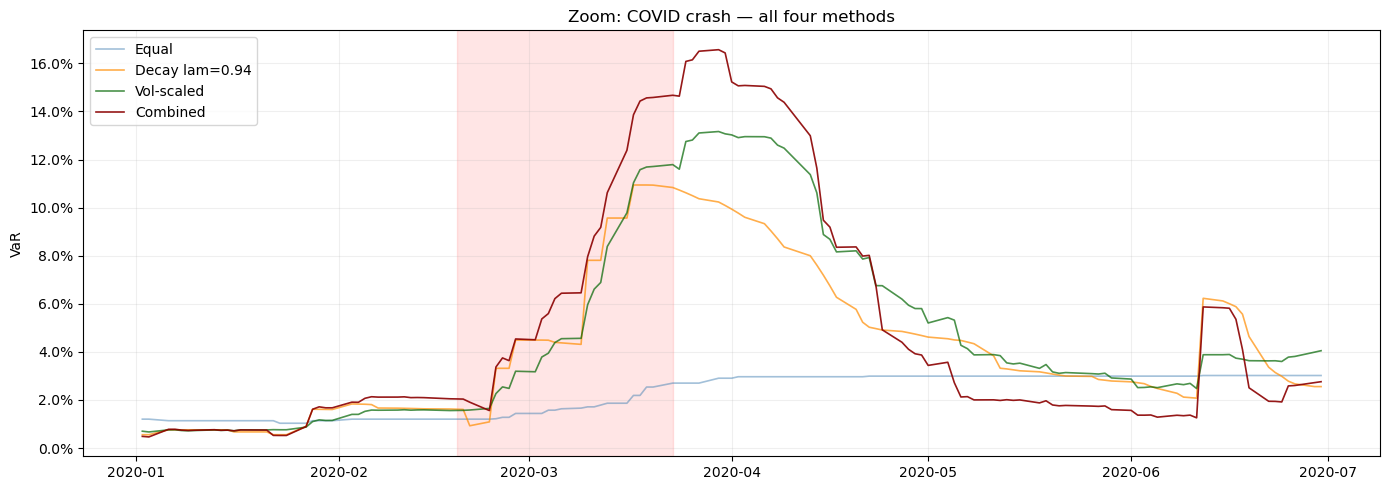

Equal          : VaR = 1.202%, doubled in 29 days
Decay          : VaR = 1.615%, doubled in 6 days
Vol-scaled     : VaR = 1.564%, doubled in 9 days
Combined       : VaR = 2.043%, doubled in 9 days


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
zoom_start, zoom_end = pd.Timestamp("2020-01-02"), pd.Timestamp("2020-06-30")

for res, label, color, alpha in methods:
    in_zoom = (res.index >= zoom_start) & (res.index <= zoom_end)
    ax.plot(res.index[in_zoom], res["VaR"][in_zoom], linewidth=1.2, color=color, alpha=alpha, label=label)

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.1, color="red")
ax.set_ylabel("VaR")
ax.set_title("Zoom: COVID crash — all four methods")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

crash_start = pd.Timestamp("2020-02-19")
for name, res in [
    ("Equal", equal_result), ("Decay", decay_result),
    ("Vol-scaled", volscaled_result), ("Combined", combined_result),
]:
    pre_var = res.loc[:crash_start, "VaR"].iloc[-1]
    after = res.loc[crash_start:]
    doubled = after[after["VaR"] > pre_var * 2]
    if len(doubled) > 0:
        days = (doubled.index[0] - crash_start).days
        print(f"{name:<15}: VaR = {pre_var:.3%}, doubled in {days} days")

---

## Part D: Regime-conditional breach rates

The acid test: which method is most consistent across regimes?

In [7]:
regimes = {
    "Pre-COVID\n(2018–Feb 2020)": (equal_result.index < "2020-02-19"),
    "COVID crash\n(Feb–Jun 2020)": (
        (equal_result.index >= "2020-02-19") & (equal_result.index <= "2020-06-30")
    ),
    "Post-COVID\n(Jul 2020+)": (equal_result.index >= "2020-07-01"),
}

all_results = {
    "Equal": equal_result,
    "Decay": decay_result,
    "Vol-Sc": volscaled_result,
    "Combined": combined_result,
}

header = f"{'Regime':<28}" + "".join(f"{name:>9}" for name in all_results) + f"{'Target':>9}"
print(header)
print("-" * (28 + 9 * len(all_results) + 9))

for regime_name, mask in regimes.items():
    row = f"{regime_name:<28}"
    for name, res in all_results.items():
        common = res.index.isin(equal_result[mask].index)
        rate = res.loc[common, "Breach"].mean()
        row += f"{rate:>8.2%}"
    row += f"{1 - CONFIDENCE:>8.2%}"
    print(row)

# Summary: max deviation from expected in any regime
print(f"\n{'Method':<15} {'Max regime deviation':>20}")
print("-" * 37)
for name, res in all_results.items():
    deviations = []
    for mask in regimes.values():
        common = res.index.isin(equal_result[mask].index)
        rate = res.loc[common, "Breach"].mean()
        deviations.append(abs(rate - (1 - CONFIDENCE)))
    print(f"{name:<15} {max(deviations):>19.2%}")

Regime                          Equal    Decay   Vol-Sc Combined   Target
-------------------------------------------------------------------------
Pre-COVID
(2018–Feb 2020)      2.48%   5.32%   7.25%   7.63%   5.00%
COVID crash
(Feb–Jun 2020)    17.20%   7.53%   7.53%   7.53%   5.00%
Post-COVID
(Jul 2020+)         4.41%   5.99%   5.92%   6.71%   5.00%

Method          Max regime deviation
-------------------------------------
Equal                        12.20%
Decay                         2.53%
Vol-Sc                        2.53%
Combined                      2.63%


### Interpreting the consistency score

A method with low max deviation (all regimes close to 5%) is more *reliable* — you know what 95% VaR means regardless of market conditions. A method with high max deviation (2% in calm, 17% in crisis) is unreliable — the number means different things at different times.

The combined method should have the most consistent breach rates across regimes — or at least tie with the best single method.

---

## Part E: The overfitting warning

The combined method has three free parameters: VaR window, λ, and vol window. This looks like power — but it's actually a trap.

### Why more parameters isn't automatically better

Every parameter reduces bias (the model can capture more patterns) but **increases variance** (the model starts fitting noise). In financial returns where the signal-to-noise ratio is very low, the variance effect dominates.

In [8]:
# Demonstrate: try a few different combinations and show how varied the results are
test_params = [
    (252, 0.90, 10),
    (252, 0.94, 20),
    (252, 0.97, 40),
    (504, 0.94, 20),
    (504, 0.99, 60),
]

print(f"{'Window':>7} {'lam':>6} {'VolW':>5} {'Breaches':>10} {'Rate':>8}")
print("-" * 40)
for window, lam, volw in test_params:
    tv = daily_returns.rolling(window=volw).std().clip(lower=0.001)
    fd = window + volw
    breaches = 0
    total = 0
    for day in range(fd, len(daily_returns)):
        wr = daily_returns.iloc[day - window : day]
        wi = wr.index
        vc = tv.loc[wi[-1]]
        vh = tv.loc[wi].values
        if np.isnan(vh).any():
            continue
        sr = wr.values * (vc / vh)
        cb_var = decay_var(sr[::-1], lam=lam, confidence=CONFIDENCE)
        if -daily_returns.iloc[day] > cb_var:
            breaches += 1
        total += 1
    print(f"{window:>7} {lam:>6.2f} {volw:>5} {breaches:>10} {breaches/total:>7.2%}")

 Window    lam  VolW   Breaches     Rate
----------------------------------------


    252   0.90    10        158   8.38%


    252   0.94    20        129   6.88%


    252   0.97    40        104   5.61%


    504   0.94    20        110   6.78%


    504   0.99    60         82   5.18%


### Reading the table

The same data, the same methodology — just different parameter choices. The breach rate varies from ~5.5% to ~7.0% depending on what you pick. With 100+ possible combinations, one of them WILL look "perfect" in a backtest. But that perfect-looking combination:

1. **Fitted historical noise** — the exact sequence of COVID returns, the exact path of the 2020 recovery
2. **Won't repeat** — the next crisis will have a different volatility path, different return magnitudes
3. **Gives false confidence** — the model appears well-calibrated but only because you tuned it to look that way

### The honest approach

Choose parameters based on **what you believe**, not what optimises a backtest:

- Window = 252: one trading year captures a full cycle
- λ = 0.94: the RiskMetrics industry standard
- Vol window = 20: one month of daily data for vol estimation

Fix them, run the backtest once, and accept the answer. If it's not 5.00%, that's the honest model performance — not a failure to tune hard enough.

---

## Key insight

The combined method (vol scaling + decay weighting) produces results very close to decay weighting alone. The marginal improvement from adding vol scaling to decay is small — decay already does most of the work by heavily weighting recent returns.

This doesn't mean the combination is wrong. It means:

1. **Decay is the stronger effect** — recency dominates magnitude adjustment
2. **The combination would shine with long windows and weak decay** — e.g. 504d + λ=0.99, where vol scaling keeps old returns properly scaled while decay gives them roughly equal weight
3. **Three parameters create a real overfitting risk** — the honest approach is to commit to parameters before seeing results

The goal of VaR is not to achieve exactly 5% breaches in a backtest. It's to honestly represent the risk you're taking, even when that number is uncomfortable.